In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    set_feature_names,
    add_degree_feature,
    add_neighborhood_summary_features,
    add_two_hop_summary_features,
    add_feature_interactions,
)
from wildfire_gnn.data.graph_splitters import attach_masks_from_split_file, print_mask_summary

In [3]:
CONFIG_PATH = "configs/gnn_config_gat_uncertainty.yaml"
config = load_yaml_config(CONFIG_PATH)
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

data = set_feature_names(data, config["data"]["raw_feature_names"])

data.y_raw = data.y.clone()

if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_min=("min" in aggs),
        add_residual=("residual" in aggs),
        add_contrast=("contrast" in aggs),
    )

if config["feature_engineering"].get("add_two_hop_features", False):
    aggs2 = set(config["feature_engineering"].get("two_hop_aggs", []))
    data = add_two_hop_summary_features(
        data,
        add_mean=("mean" in aggs2),
        add_std=("std" in aggs2),
    )

if config["feature_engineering"].get("add_feature_interactions", False):
    data = add_feature_interactions(
        data,
        config["feature_engineering"]["interaction_pairs"]
    )

print_mask_summary(data)
print("x shape:", data.x.shape)

Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000
x shape: torch.Size([300000, 171])


In [4]:
train_outputs = pipeline.train(data, stage="stage2")
train_outputs.history.tail()

,epoch,train_loss,val_loss
75,76,-2.141866,-2.339553
76,77,-2.192150,-2.364455
77,78,-2.262253,-2.528214
78,79,-2.342476,-2.708999
79,80,-2.368202,-2.801595


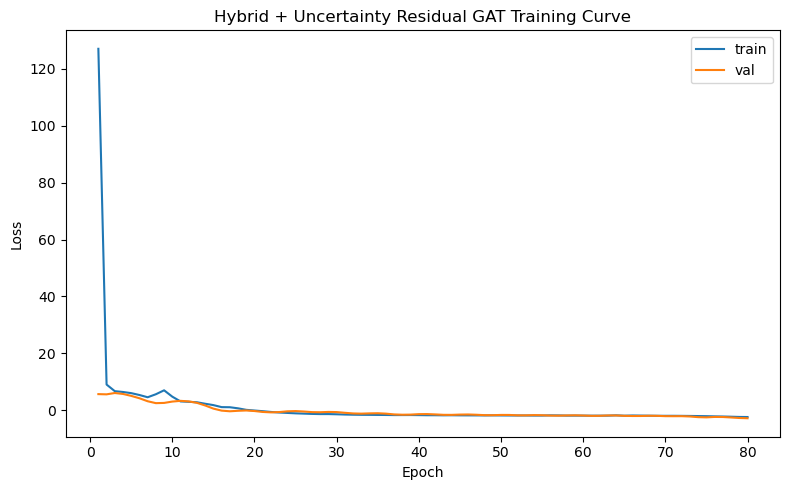

In [5]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Hybrid + Uncertainty Residual GAT Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/gat_uncertainty_loss_curve.png", dpi=200)
plt.show()